<a href="https://colab.research.google.com/github/alirezakiann/snappfood-sentiment/blob/main/notebooks/04_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 - LSTM Model (PyTorch)
TF-IDF treats a review as a "bag of words" and ignores word order. That's why the baseline
got «کیفیت خوب بود ولی خیلی دیر رسید» wrong: it can't see that the part after «ولی» (but) carries the main message.

An **LSTM** reads the review word by word, in order, and keeps a running "memory" of what it has read.

Questions this notebook answers:
1. Can an LSTM beat the TF-IDF baseline (86.4% accuracy)?
2. Should we keep stopwords for a model that reads word order?
3. Does it handle «... ولی ...» (but) reviews better?

**Before running:** Runtime → Change runtime type → **T4 GPU**.

## 0. Setup

In [1]:
!pip install -q hazm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.2/887.2 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
BASE_DIR = "/content/drive/MyDrive/snappfood-sentiment"
PROC_DIR = f"{BASE_DIR}/processed"
MODEL_DIR = f"{BASE_DIR}/models"
os.makedirs(MODEL_DIR, exist_ok=True)

for name in ["train", "val", "test"]:
    print(name, "found:", os.path.exists(f"{PROC_DIR}/{name}.csv"))
print("baseline model found:", os.path.exists(f"{MODEL_DIR}/baseline_tfidf_model.joblib"))

Mounted at /content/drive
train found: True
val found: True
test found: True
baseline model found: True


In [3]:
import re
import time
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from hazm import Normalizer, stopwords_list

pd.set_option("display.max_colwidth", 150)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", message="This pattern")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("No GPU! Runtime -> Change runtime type -> T4 GPU, then run again from the top.")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()

Device: cuda


## 1. Load data and create a "light" version of the text
In notebook 02 we removed stopwords. That's fine for TF-IDF, but an LSTM reads word order, and small words
like «مثل», «قبل» or «بود» can matter. So we build a second version that is cleaned the same way
**but keeps all words**, and let the experiment decide which is better.

In [4]:
train = pd.read_csv(f"{PROC_DIR}/train.csv")
val = pd.read_csv(f"{PROC_DIR}/val.csv")
test = pd.read_csv(f"{PROC_DIR}/test.csv")

# same cleaning function as notebook 02
KEEP = {
    "نه", "نبود", "نیست", "نیستند", "ندارد", "ندارند", "نباید", "نمی‌شود", "هیچ", "بدون", "عدم", "غیر", "بی",
    "اما", "ولی", "بلکه", "حتی", "فقط", "تنها",
    "خیلی", "بسیار", "بسیاری", "کاملا", "کامل", "زیاد", "زیادی", "کم", "کمی", "بیش", "بیشتر", "پر", "کافی",
    "عالی", "خوب", "خوبی", "بهتر", "بهترین", "مناسب", "متاسفانه", "جدی",
    "رسید", "رسیدن", "دیر", "هنوز", "همیشه", "همواره", "دوباره",
}
STOPWORDS = set(stopwords_list()) - KEEP
normalizer = Normalizer()

URL_RE = re.compile(r"https?://\S+|www\.\S+")
REPEAT_RE = re.compile(r"(.)\1{2,}")
EMOJI_RE = re.compile("[\U0001F300-\U0001FAFF\U00002600-\U000027BF]")
PERSIAN = "\u0621-\u063A\u0641-\u064A\u067E\u0686\u0698\u06A9\u06AF\u06CC\u200c"
EMOJI_CHARS = "\U0001F300-\U0001FAFF\U00002600-\U000027BF"
NOT_ALLOWED_RE = re.compile(f"[^{PERSIAN}{EMOJI_CHARS}a-z\\s]")

def clean_text(text, stopwords=STOPWORDS):
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = normalizer.normalize(text)
    text = REPEAT_RE.sub(r"\1", text)
    text = EMOJI_RE.sub(lambda m: f" {m.group(0)} ", text)
    text = NOT_ALLOWED_RE.sub(" ", text)
    tokens = [t.strip("\u200c") for t in text.split()]
    tokens = [t for t in tokens if t and t not in stopwords and (len(t) > 1 or EMOJI_RE.match(t))]
    return " ".join(tokens)

for d in (train, val, test):
    d["clean_text"] = d["clean_text"].fillna("")
    d["light_text"] = d["comment"].apply(lambda t: clean_text(t, stopwords=set()))

train[["comment", "clean_text", "light_text"]].head(5)

,comment,clean_text,light_text
0,راضیم ازتون مثل همیشه …سربلند باشید,راضیم ازتون همیشه سربلند باشید,راضیم ازتون مثل همیشه سربلند باشید
1,صابونی که فرستاده بودند پنپش شکسته و غیر قابل استفاده بود,صابونی فرستاده پنپش شکسته غیر قابل‌استفاده,صابونی که فرستاده بودند پنپش شکسته غیر قابل‌استفاده بود
2,پرتغال پوسیده بود. انار سفید و کاملا ترش. گلابی خیلی بد. به جای سیب سبز، سیب زرد ارسال شد! فلفل سبز بی کیفیت.,پرتغال پوسیده انار سفید کاملا ترش گلابی خیلی بد سیب سبز سیب زرد ارسال فلفل سبز بی‌کیفیت,پرتغال پوسیده بود انار سفید کاملا ترش گلابی خیلی بد به جای سیب سبز سیب زرد ارسال شد فلفل سبز بی‌کیفیت
3,مثل همیشه تازه و خوشمزه ممنون,همیشه تازه خوشمزه ممنون,مثل همیشه تازه خوشمزه ممنون
4,سفارش ما بعد از ۲ ساعت رسید دستمان,سفارش ساعت رسید دستمان,سفارش ما بعد از ساعت رسید دستمان


## 2. From words to numbers: vocabulary and sequences
TF-IDF gave each review one long vector. An LSTM needs a **sequence**: each word is replaced by its ID in a vocabulary.
- words seen fewer than 2 times in train → `<unk>` (unknown)
- short reviews are padded with `<pad>` so a batch has equal lengths
- very long reviews are cut to `MAX_LEN` words

In [5]:
lengths = train["light_text"].str.split().str.len()
print(lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))

MAX_LEN = int(min(lengths.quantile(0.95), 100))
print("\nMAX_LEN =", MAX_LEN, "-> covers 95% of reviews completely")

count    55280.0
mean        17.4
std         14.7
min          2.0
50%         13.0
90%         35.0
95%         46.0
99%         72.0
max        337.0
Name: light_text, dtype: float64

MAX_LEN = 46 -> covers 95% of reviews completely


In [6]:
PAD, UNK = 0, 1

def build_vocab(texts, min_freq=2):
    counts = Counter(tok for t in texts for tok in t.split())
    vocab = {"<pad>": PAD, "<unk>": UNK}
    for tok, c in counts.most_common():
        if c >= min_freq:
            vocab[tok] = len(vocab)
    return vocab

def encode(text, vocab):
    ids = [vocab.get(tok, UNK) for tok in text.split()][:MAX_LEN]
    return ids if ids else [UNK]

# tiny demo
demo_vocab = build_vocab(train["light_text"])
example = train["light_text"].iloc[0]
print(example)
print(encode(example, demo_vocab))
print("vocabulary size:", len(demo_vocab))

راضیم ازتون مثل همیشه سربلند باشید
[819, 509, 54, 33, 4873, 368]
vocabulary size: 13271


In [7]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.x = [torch.tensor(encode(t, vocab)) for t in texts]
        self.y = torch.tensor(labels.values, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.x[i], self.y[i]

def collate(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    return pad_sequence(seqs, batch_first=True, padding_value=PAD), lengths, torch.stack(labels)

## 3. The model
```
word IDs -> Embedding -> BiLSTM -> Dropout -> Linear -> score
```
- **Embedding**: turns each word ID into a vector of 128 numbers, learned during training. Words used in similar ways end up with similar vectors.
- **BiLSTM**: one LSTM reads the review left→right, another right→left. We join their final memories. Reading backwards helps the model "know" what comes after «ولی» while reading what comes before it.
- **Dropout**: randomly switches off 40% of the numbers during training. This is regularization, just like `C` in notebook 03.
- **Linear**: turns the memory into one score. Positive score → HAPPY.

In [8]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, lengths):
        emb = self.dropout(self.embedding(x))
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)          # h: final memory of each direction
        h = torch.cat([h[-2], h[-1]], dim=1)   # forward + backward
        return self.fc(self.dropout(h)).squeeze(1)

print(SentimentLSTM(vocab_size=len(demo_vocab)))
n_params = sum(p.numel() for p in SentimentLSTM(len(demo_vocab)).parameters())
print(f"parameters: {n_params:,}")

SentimentLSTM(
  (embedding): Embedding(13271, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)
parameters: 1,963,137


## 4. Training with early stopping
One **epoch** = the model sees all training reviews once.
After each epoch we check validation F1. If it doesn't improve for 2 epochs in a row, we stop
and keep the best version (**early stopping**, another guard against overfitting).

In [9]:
def run_epoch(model, loader, loss_fn, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, all_probs, all_y = 0.0, [], []

    with torch.set_grad_enabled(training):
        for x, lengths, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x, lengths)
            loss = loss_fn(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_probs.append(torch.sigmoid(logits).detach().cpu())
            all_y.append(y.cpu())

    probs = torch.cat(all_probs).numpy()
    y_true = torch.cat(all_y).numpy().astype(int)
    preds = (probs >= 0.5).astype(int)
    return total_loss / len(y_true), f1_score(y_true, preds, average="macro"), probs


def train_lstm(text_col, max_epochs=10, patience=2, batch_size=128, lr=1e-3):
    set_seed()
    vocab = build_vocab(train[text_col])
    train_dl = DataLoader(ReviewDataset(train[text_col], train["sentiment"], vocab),
                          batch_size=batch_size, shuffle=True, collate_fn=collate)
    val_dl = DataLoader(ReviewDataset(val[text_col], val["sentiment"], vocab),
                        batch_size=256, collate_fn=collate)

    model = SentimentLSTM(len(vocab)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    history, best_f1, best_state, bad_epochs = [], 0, None, 0
    for epoch in range(1, max_epochs + 1):
        start = time.time()
        tr_loss, tr_f1, _ = run_epoch(model, train_dl, loss_fn, optimizer)
        va_loss, va_f1, _ = run_epoch(model, val_dl, loss_fn)
        history.append(dict(epoch=epoch, train_loss=tr_loss, val_loss=va_loss, train_f1=tr_f1, val_f1=va_f1))
        print(f"[{text_col}] epoch {epoch:2d} | train loss {tr_loss:.4f} F1 {tr_f1:.4f} | "
              f"val loss {va_loss:.4f} F1 {va_f1:.4f} | {time.time() - start:.0f}s")

        if va_f1 > best_f1:
            best_f1, bad_epochs = va_f1, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping. Best val F1 = {best_f1:.4f}")
                break

    model.load_state_dict(best_state)
    return dict(model=model, vocab=vocab, history=pd.DataFrame(history), best_val_f1=best_f1)

## 5. Experiment: with vs. without stopwords

In [10]:
%%time
runs = {}
for col in ["clean_text", "light_text"]:
    runs[col] = train_lstm(col)
    print()

[clean_text] epoch  1 | train loss 0.4247 F1 0.8048 | val loss 0.3488 F1 0.8532 | 7s
[clean_text] epoch  2 | train loss 0.3540 F1 0.8446 | val loss 0.3362 F1 0.8593 | 4s
[clean_text] epoch  3 | train loss 0.3325 F1 0.8555 | val loss 0.3276 F1 0.8657 | 6s
[clean_text] epoch  4 | train loss 0.3182 F1 0.8628 | val loss 0.3212 F1 0.8664 | 4s
[clean_text] epoch  5 | train loss 0.3052 F1 0.8693 | val loss 0.3235 F1 0.8662 | 4s
[clean_text] epoch  6 | train loss 0.2921 F1 0.8756 | val loss 0.3358 F1 0.8657 | 6s
Early stopping. Best val F1 = 0.8664

[light_text] epoch  1 | train loss 0.4327 F1 0.7985 | val loss 0.3552 F1 0.8505 | 5s
[light_text] epoch  2 | train loss 0.3576 F1 0.8428 | val loss 0.3394 F1 0.8602 | 5s
[light_text] epoch  3 | train loss 0.3345 F1 0.8551 | val loss 0.3462 F1 0.8569 | 5s
[light_text] epoch  4 | train loss 0.3175 F1 0.8638 | val loss 0.3384 F1 0.8659 | 5s
[light_text] epoch  5 | train loss 0.3050 F1 0.8704 | val loss 0.3240 F1 0.8680 | 6s
[light_text] epoch  6 | tra

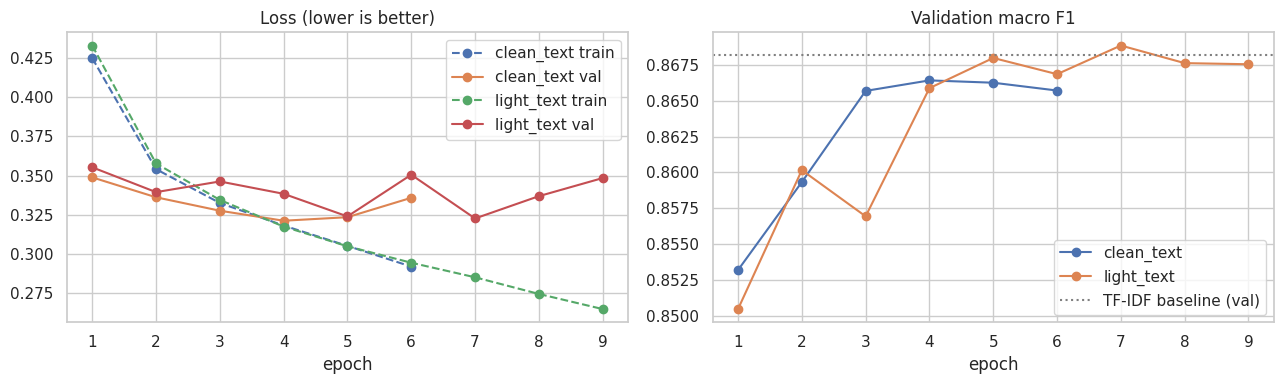

clean_text  best val F1 = 0.8664
light_text  best val F1 = 0.8688


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for col, run in runs.items():
    h = run["history"]
    axes[0].plot(h["epoch"], h["train_loss"], "o--", label=f"{col} train")
    axes[0].plot(h["epoch"], h["val_loss"], "o-", label=f"{col} val")
    axes[1].plot(h["epoch"], h["val_f1"], "o-", label=col)
axes[0].set_title("Loss (lower is better)"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].set_title("Validation macro F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
axes[1].axhline(0.8682, color="gray", ls=":", label="TF-IDF baseline (val)")
axes[1].legend()
plt.tight_layout()
plt.show()

for col, run in runs.items():
    print(f"{col:11} best val F1 = {run['best_val_f1']:.4f}")

When the train loss keeps going down but the validation loss starts going **up**, the model has started memorizing. Early stopping catches that point.

In [12]:
best_col = max(runs, key=lambda c: runs[c]["best_val_f1"])
lstm, vocab = runs[best_col]["model"], runs[best_col]["vocab"]
print("Using:", best_col)

Using: light_text


## 6. Final test and comparison with the baseline
The test set is used once, for both models.

In [13]:
test_dl = DataLoader(ReviewDataset(test[best_col], test["sentiment"], vocab), batch_size=256, collate_fn=collate)
_, _, test_probs = run_epoch(lstm, test_dl, nn.BCEWithLogitsLoss())
test["lstm_pred"] = (test_probs >= 0.5).astype(int)

baseline = joblib.load(f"{MODEL_DIR}/baseline_tfidf_model.joblib")
test["base_pred"] = baseline.predict(test["clean_text"])

y = test["sentiment"]
summary = pd.DataFrame({
    "TF-IDF + SVM": [accuracy_score(y, test["base_pred"]), f1_score(y, test["base_pred"], average="macro")],
    "BiLSTM":       [accuracy_score(y, test["lstm_pred"]), f1_score(y, test["lstm_pred"], average="macro")],
}, index=["accuracy", "macro F1"])
summary.round(4)

,TF-IDF + SVM,BiLSTM
accuracy,0.8641,0.8598
macro F1,0.8636,0.8594


              precision    recall  f1-score   support

         SAD     0.8307    0.9060    0.8667      3477
       HAPPY     0.8951    0.8130    0.8521      3433

    accuracy                         0.8598      6910
   macro avg     0.8629    0.8595    0.8594      6910
weighted avg     0.8627    0.8598    0.8594      6910



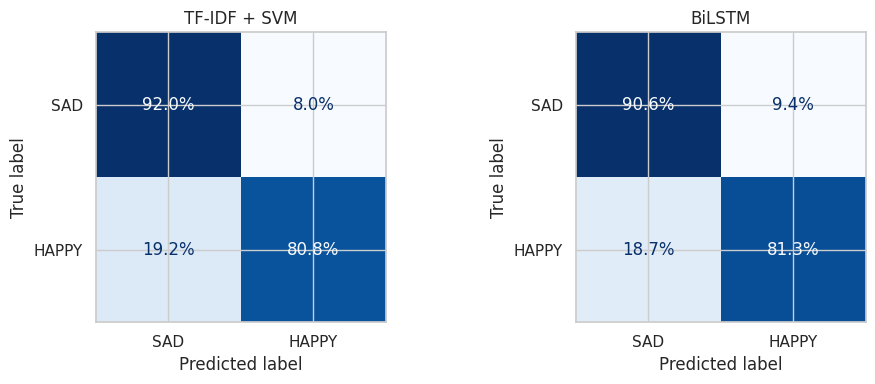

In [14]:
print(classification_report(y, test["lstm_pred"], target_names=["SAD", "HAPPY"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in [(axes[0], "base_pred", "TF-IDF + SVM"), (axes[1], "lstm_pred", "BiLSTM")]:
    ConfusionMatrixDisplay.from_predictions(y, test[col], display_labels=["SAD", "HAPPY"],
                                            cmap="Blues", normalize="true", values_format=".1%", ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 7. Did word order help where we expected it to?
We compare both models on specific types of reviews:
- reviews with «ولی» / «اما» (but): mixed reviews, the baseline's weak spot
- reviews with negation («نبود», «نیست», «نداشت»)
- short vs. long reviews

In [15]:
groups = {
    "all reviews":            pd.Series(True, index=test.index),
    "with ولی / اما (but)":   test["comment"].str.contains(r"\b(?:ولی|اما)\b", regex=True),
    "with negation":          test["comment"].str.contains(r"\b(?:نبود|نیست|نداشت|نبودن)\b", regex=True),
    "short (<= 10 words)":    test["light_text"].str.split().str.len() <= 10,
    "long (> 30 words)":      test["light_text"].str.split().str.len() > 30,
}

rows = []
for name, mask in groups.items():
    part = test[mask]
    rows.append({"group": name, "reviews": len(part),
                 "TF-IDF + SVM": accuracy_score(part["sentiment"], part["base_pred"]),
                 "BiLSTM": accuracy_score(part["sentiment"], part["lstm_pred"])})
by_group = pd.DataFrame(rows)
by_group["difference"] = by_group["BiLSTM"] - by_group["TF-IDF + SVM"]
by_group.round(4)

,group,reviews,TF-IDF + SVM,BiLSTM,difference
0,all reviews,6910,0.8641,0.8598,-0.0043
1,with ولی / اما (but),1291,0.8048,0.7862,-0.0186
2,with negation,1319,0.8044,0.8105,0.0061
3,short (<= 10 words),2724,0.8689,0.8664,-0.0026
4,long (> 30 words),937,0.8559,0.8453,-0.0107


In [16]:
fixed = test[(test["lstm_pred"] == test["sentiment"]) & (test["base_pred"] != test["sentiment"])]
broken = test[(test["lstm_pred"] != test["sentiment"]) & (test["base_pred"] == test["sentiment"])]
print(f"LSTM right, baseline wrong: {len(fixed):,}")
print(f"LSTM wrong, baseline right: {len(broken):,}")
print(f"both wrong:                 {((test['lstm_pred'] != y) & (test['base_pred'] != y)).sum():,}")

print("\n--- LSTM fixed these (mixed reviews) ---")
fixed_mixed = fixed[fixed["comment"].str.contains(r"\b(?:ولی|اما)\b", regex=True)]
fixed_mixed[["comment", "label"]].head(10)

LSTM right, baseline wrong: 189
LSTM wrong, baseline right: 219
both wrong:                 750

--- LSTM fixed these (mixed reviews) ---


,comment,label
123,من همیشه همین پای سیب تخت رو سفارش میدم و همیشه خوب بوده ولی اینبار هم ظاهر به هم ریخته داشت و هم کاملا طعم روغن مونده داشت,SAD
192,در زمان سفارش قید شده بود که از شکلات نوتلا استفاده نشود ولی به مقدار بسیار زیادی نوتلا داشت. ظرف وافل نیز احتمالا در موقع حمل برعکس شده بود. چون ...,SAD
194,شکری برشی پنج ستاره نان خانه‌ای پنج ستاره حمل توسط پیک (با کلی خواهش ولی پنج ستاره) تا اینجا ممنون، کوکتل خلال دار خیلی بد بود و سفت بود و تازه نب...,SAD
292,همه چیز عالی بود بغیر از موهیتو. من قبلا موهیتو باروژ رو خورده بودم، طعم و مزه بسیار عالیی داشت ولی امروز اصلا قابل خوردن نبود.,HAPPY
358,یک ساعت طول کشید مثلا قراره فست فود باشه مرغ سوخاری خوب بود ولی پیتزا مرغ تنوری خیلی مزه بیخودی داشت حجم پپرونی هم کم بود,SAD
415,با سلام و احترام، سالاد بسیار عالی بود اما پیتزا متاسفانه طعم خوبی نداشته و سوسیس‌های ژاپنی خام بودند …,SAD
457,پیتزا اصلا خوشمزه نبود بیمزه و بی طعم ولی هات داگ عالی بود,HAPPY
578,/۵ طول کشید تا برسه اینجا با اینکه نزدیکه واقعا، غذا‌ها کاملا سرد بود ولی با همه این وجود فقط چون خیلی خوشمزس باز سفارش میدم ولی دیگه اینسری خیلیی...,SAD
677,طعم و کیفیتش جالب بود واسم اما خیلی قیمتش نصبت به خودش بالا‌تر بود ارزش خرید نداشت,HAPPY
786,این سوپر مارکت در نزدیکی محله ما نیست و فقط به خاطر داشتن یک جنس خاص در منوی سوپر که خواهان آن بودیم سفارش را به این سوپر محول کردیم؛ ولی متاسفانه...,SAD


In [17]:
print("--- LSTM broke these ---")
broken[["comment", "label"]].head(10)

--- LSTM broke these ---


,comment,label
10,جوجه‌اش زیاد عالی نبود و برنج هم ایرانی نیود,HAPPY
50,ماکارون‌ها خیلی کوچک بودند,HAPPY
52,سس تند خواسته بودم که متاسفانه توجه نشد,SAD
56,پیتزا بک فایر رو توصیه نمی‌کنم به لحاظ قیمت و کیفیت خوب نیست. پپرونی و چهارفصل پیتزاهای خوبی هستند.,SAD
62,غذاها با عکساشون خیلی فرق دارن.,SAD
82,سیب زمینی ویژه پیشنهاد نمیکنم پنیر داخلش مزه خوبی به غذا نداده بود این پنیر تو هات داگ هم بود که جالب نبود ولی پیتزا خوب بود,SAD
131,زمان زیاد آماده شدن و ارسال غذا,HAPPY
256,باسلام وخسته نباشی در مورد کیفیت الانه ۲ سفارش اخیر بنده پیتزا باروژ بسیار با کیفیت قبل یا سال قبل بهمن ماه کیفیت صد در صدی به سی یا چهل درصد رسید...,SAD
263,نوشیدنی درخواستی اسپرایت بوده اما کوکا ارسال شد,HAPPY
266,روی روغن قیمتش ۱۱۴۰۰ ثبت شده و اینجا ۱۲۵۰۰، کارخونه خودش به اندازه کافی روی جنس میکشه که مغازه دار خودش کلی سود ببره ولی جالبه ک باز مغازه دار هم ...,HAPPY


## 8. Try it on your own sentences

In [18]:
def predict_lstm(texts):
    lstm.eval()
    seqs = [torch.tensor(encode(clean_text(t, stopwords=set() if best_col == "light_text" else STOPWORDS), vocab))
            for t in texts]
    lengths = torch.tensor([len(s) for s in seqs])
    x = pad_sequence(seqs, batch_first=True, padding_value=PAD).to(DEVICE)
    with torch.no_grad():
        return torch.sigmoid(lstm(x, lengths)).cpu().numpy()

my_reviews = [
    "غذا خیلی خوشمزه و داغ بود، ممنون",
    "اصلا خوب نبود، سرد رسید",
    "کیفیت خوب بود ولی خیلی دیر رسید",
    "خیلی دیر رسید ولی کیفیت خوب بود",
    "بد نبود",
    "پیتزا سوخته بود و پیک هم بی‌ادب بود",
]

probs = predict_lstm(my_reviews)
base = baseline.predict([clean_text(r) for r in my_reviews])
for r, p, b in zip(my_reviews, probs, base):
    print(f"LSTM: {'HAPPY' if p >= 0.5 else 'SAD':5} ({p:.2f}) | SVM: {'HAPPY' if b == 1 else 'SAD':5} <- {r}")

LSTM: HAPPY (1.00) | SVM: HAPPY <- غذا خیلی خوشمزه و داغ بود، ممنون
LSTM: SAD   (0.05) | SVM: SAD   <- اصلا خوب نبود، سرد رسید
LSTM: HAPPY (0.80) | SVM: HAPPY <- کیفیت خوب بود ولی خیلی دیر رسید
LSTM: HAPPY (0.97) | SVM: HAPPY <- خیلی دیر رسید ولی کیفیت خوب بود
LSTM: HAPPY (0.80) | SVM: HAPPY <- بد نبود
LSTM: SAD   (0.05) | SVM: SAD   <- پیتزا سوخته بود و پیک هم بی‌ادب بود


The 3rd and 4th sentences have the same words in a different order. TF-IDF **must** give them the same answer; the LSTM doesn't have to.

## 9. Save the model

In [19]:
torch.save({"state_dict": lstm.state_dict(), "vocab": vocab, "max_len": MAX_LEN, "text_col": best_col},
           f"{MODEL_DIR}/lstm_model.pt")
print("Saved to:", f"{MODEL_DIR}/lstm_model.pt")

Saved to: /content/drive/MyDrive/snappfood-sentiment/models/lstm_model.pt


## 10. Key findings
- **The LSTM did not beat the baseline:** BiLSTM reached **86.0% accuracy / 0.859 macro F1** on test, vs. **86.4% / 0.864** for TF-IDF + Linear SVM. A ~5M-parameter deep model was slightly worse than a linear model trained in under a second.
- **Keeping stopwords helped the LSTM a little:** best validation F1 was 0.8688 with all words kept vs. 0.8664 with stopwords removed. The gap is small and based on a single run.
- **Overfitting is visible:** train loss keeps falling while validation loss stops improving after epoch 4-5. Early stopping picked the best epoch automatically.
- **The "but" hypothesis was rejected:** on reviews with «ولی» / «اما», the LSTM scored 78.6% vs. 80.5% for the baseline. Both models drop about 6 points on these mixed reviews, so they are hard in general. The LSTM was slightly better only on negation (+0.6).
- **Word order is sensed, but weakly:** «کیفیت خوب بود ولی خیلی دیر رسید» gets P(happy)=0.80 and the reversed sentence gets 0.97. TF-IDF must give both the same answer.
- **Shared errors point to a data ceiling:** 750 test reviews are misclassified by both models (~80% of each model's errors), while only 189 / 219 are fixed / broken by switching models. Many of these look like label errors (e.g. «ماکارون‌ها خیلی کوچک بودند» labeled HAPPY).
- **Why TF-IDF wins here:** reviews are short (median 13 words), the LSTM learns word vectors from scratch on only 55k reviews, and label noise caps both models. Next step: analyze the shared errors instead of adding model complexity.